## Install & Import

In [ ]:
!pip install xgboost imbalanced-learn scikit-learn pandas numpy scipy --quiet

In [9]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, cohen_kappa_score, balanced_accuracy_score)
from sklearn.cluster import KMeans
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from scipy.stats import wilcoxon

print('All libraries imported successfully.')

All libraries imported successfully.


In [1]:
import pandas as pd
import numpy as np
import random
from google.colab import drive

# Step 0: Install required packages
!pip install networkx matplotlib numpy pandas scikit-learn xgboost

# Step 1: Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install ucimlrepo

In [3]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
chronic_kidney_disease = fetch_ucirepo(id=336)

# data (as pandas dataframes)
X = chronic_kidney_disease.data.features
y = chronic_kidney_disease.data.targets

# metadata
print(chronic_kidney_disease.metadata)

# variable information
print(chronic_kidney_disease.variables)


{'uci_id': 336, 'name': 'Chronic Kidney Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/336/chronic+kidney+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/336/data.csv', 'abstract': 'This dataset can be used to predict the chronic kidney disease and it can be collected from the hospital nearly 2 months of period.', 'area': 'Other', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 400, 'num_features': 24, 'feature_types': ['Real'], 'demographics': ['Age'], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2015, 'last_updated': 'Mon Mar 04 2024', 'dataset_doi': '10.24432/C5G020', 'creators': ['L. Rubini', 'P. Soundarapandian', 'P. Eswaran'], 'intro_paper': None, 'additional_info': {'summary': 'We use the following representation to collect the dataset\r\n                        age\t\t-\tage\t\r\n\t\t\tbp\t\t-\tblood pressure\r\n\t\t\tsg\t

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder



In [5]:
print('--- Ensuring Y is Integer Encoded ---')
if y['class'].dtype == 'object':
    le_y = LabelEncoder()
    y = pd.Series(le_y.fit_transform(y), name='class')
    Class_names = list(le_y.classes_)
    print(f"  Y has been integer encoded. New Class_names: {Class_names}")
else:
    print("  Y is already integer encoded.")

print('\n--- Applying Label Encoding to categorical features in X ---')
object_cols_before_encoding = X.select_dtypes(include='object').columns.tolist()
if not object_cols_before_encoding:
    print("  No object type columns found in X, skipping Label Encoding.")
else:
    for col in object_cols_before_encoding:
        # Convert to string to handle potential NaN values as a separate category 'nan'
        X[col] = X[col].astype(str)
        le_x = LabelEncoder()
        X[col] = pd.Series(le_x.fit_transform(X[col]), index=X.index, dtype=np.int64)
        print(f"  Applied Label Encoding to '{col}'. Contains {len(le_x.classes_)} unique values including 'nan' if present.")


print('\n--- Handling Missing Values in X ---')
# Impute missing values in numerical (float) columns with the mean
float_cols = X.select_dtypes(include=['float64']).columns
for col in float_cols:
    if X[col].isnull().any():
        mean_val = X[col].mean()
        X[col].fillna(mean_val, inplace=True)
        print(f"  Filled missing values in '{col}' (float) with mean: {mean_val:.2f}")

# Impute missing values in integer columns (including newly encoded categorical ones) with the mode
int_cols = X.select_dtypes(include=['int64']).columns
for col in int_cols:
    if X[col].isnull().any():
        # Mode might return multiple values, pick the first one
        mode_val = X[col].mode()[0]
        X[col].fillna(mode_val, inplace=True)
        print(f"  Filled missing values in '{col}' (int) with mode: {mode_val}")

print('\n--- Status After Handling Missing Values and Encoding ---')
print('X head:')
display(X.head())
print('\nX dtypes:')
display(X.dtypes)
print('\nMissing values per column in X (should be all 0):')
display(X.isnull().sum())

--- Ensuring Y is Integer Encoded ---
  Y has been integer encoded. New Class_names: ['ckd', 'ckd\t', 'notckd']

--- Applying Label Encoding to categorical features in X ---
  Applied Label Encoding to 'rbc'. Contains 3 unique values including 'nan' if present.
  Applied Label Encoding to 'pc'. Contains 3 unique values including 'nan' if present.
  Applied Label Encoding to 'pcc'. Contains 3 unique values including 'nan' if present.
  Applied Label Encoding to 'ba'. Contains 3 unique values including 'nan' if present.
  Applied Label Encoding to 'htn'. Contains 3 unique values including 'nan' if present.
  Applied Label Encoding to 'dm'. Contains 4 unique values including 'nan' if present.
  Applied Label Encoding to 'cad'. Contains 3 unique values including 'nan' if present.
  Applied Label Encoding to 'appet'. Contains 3 unique values including 'nan' if present.
  Applied Label Encoding to 'pe'. Contains 3 unique values including 'nan' if present.
  Applied Label Encoding to 'ane'. C

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/tmp/ipykernel_2085/3400625696.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].astype(str)
/tmp/ipykernel_2085/3400625696.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = pd.Series(le_x.fit_transform(X[col]), ind

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,hemo,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane
0,48.0,80.0,1.020,1.0,0.0,1,2,1,1,121.000000,...,15.4,44.0,7800.0,5.200000,2,3,1,0,1,1
1,7.0,50.0,1.020,4.0,0.0,1,2,1,1,148.036517,...,11.3,38.0,6000.0,4.707435,1,2,1,0,1,1
2,62.0,80.0,1.010,2.0,3.0,2,2,1,1,423.000000,...,9.6,31.0,7500.0,4.707435,1,3,1,2,1,2
3,48.0,70.0,1.005,4.0,0.0,2,0,2,1,117.000000,...,11.2,32.0,6700.0,3.900000,2,2,1,2,2,2
4,51.0,80.0,1.010,2.0,0.0,2,2,1,1,106.000000,...,11.6,35.0,7300.0,4.600000,1,2,1,0,1,1



X dtypes:


,0
age,float64
bp,float64
sg,float64
al,float64
su,float64
rbc,int64
pc,int64
pcc,int64
ba,int64
bgr,float64



Missing values per column in X (should be all 0):


,0
age,0
bp,0
sg,0
al,0
su,0
rbc,0
pc,0
pcc,0
ba,0
bgr,0


In [ ]:
print('\n--- Final Missing Values Check in X ---')
display(X.isnull().sum())


--- Final Missing Values Check in X ---


,0
age,0
bp,0
sg,0
al,0
su,0
rbc,0
pc,0
pcc,0
ba,0
bgr,0


In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Re-fetch the raw target data to ensure correct preprocessing
# Assuming 'chronic_kidney_disease' object is still available from cell wqvTlRN1R9v6
raw_y = chronic_kidney_disease.data.targets.copy()

# Make sure y is a 1D Series for LabelEncoder compatibility
if isinstance(raw_y, pd.DataFrame) and raw_y.shape[1] == 1:
    raw_y = raw_y.iloc[:, 0] # Convert single-column DataFrame to Series
elif isinstance(raw_y, pd.DataFrame) and raw_y.shape[1] > 1:
    # Handle cases where multiple target columns exist, or choose the specific one
    # For now, let's assume it's single column as per previous usage
    raise ValueError("Multiple target columns found in raw_y, please specify which to use.")


# Clean up 'ckd\t' label in y before encoding
print("Original y value counts before cleaning:")
print(raw_y.value_counts())
y_cleaned_str = raw_y.replace('ckd\t', 'ckd')
print("\nProcessed y value counts after replacing 'ckd\t' with 'ckd':")
print(y_cleaned_str.value_counts())


# Integer-encode labels
le = LabelEncoder()
y = pd.Series(le.fit_transform(y_cleaned_str), name='class')
Class_names = list(le.classes_)

print(f'\nDataset: {X.shape[0]} samples, {X.shape[1]} features')
print(f'Classes: {Class_names}')
print(f'Class distribution after encoding:')
print(pd.Series(le.inverse_transform(y)).value_counts())

# Update the num_Class parameter for XGBoost in models_to_evaluate after Class_names is defined
# Ensure models_to_evaluate is accessible (it should be if helpers-cell was run)
if 'models_to_evaluate' in globals() and 'XGBoost' in models_to_evaluate:
    # models_to_evaluate is a dict, and its value for 'XGBoost' is a tuple (class, params_dict)
    # We need to modify the params_dict
    # Make a mutable copy of the parameters dictionary before modifying
    xgb_class, xgb_params_original = models_to_evaluate['XGBoost']
    xgb_params_copy = xgb_params_original.copy()
    xgb_params_copy['num_Class'] = len(Class_names)
    # Update the models_to_evaluate dictionary with the modified parameters
    models_to_evaluate['XGBoost'] = (xgb_class, xgb_params_copy)
    print(f"Updated XGBoost 'num_Class' to {len(Class_names)} in models_to_evaluate.")
else:
    print("Warning: 'models_to_evaluate' or 'XGBoost' not found. Ensure helpers-cell was executed before data-cell.")

# ── Feature importance for reference / display only ───────────────────
# NOTE: top_features below is computed on the full dataset for display
# purposes ONLY.  All CV functions below recompute feature importance
# INSIDE each training fold to avoid feature-selection data leakage.
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42).fit(X, y)
importances = rf_selector.feature_importances_
top_features = X.columns[np.argsort(importances)[-10:]].tolist()

print(f'\nReference top features (full-data, display only): {top_features}')
print('(All CV runs recompute feature selection inside each fold.)')


Original y value counts before cleaning:
class
ckd       248
notckd    150
ckd\t       2
Name: count, dtype: int64

Processed y value counts after replacing 'ckd	' with 'ckd':
class
ckd       250
notckd    150
Name: count, dtype: int64

Dataset: 400 samples, 24 features
Classes: ['ckd', 'notckd']
Class distribution after encoding:
ckd       250
notckd    150
Name: count, dtype: int64

Reference top features (full-data, display only): ['sod', 'dm', 'bgr', 'rbc', 'al', 'rbcc', 'sc', 'sg', 'hemo', 'pcv']
(All CV runs recompute feature selection inside each fold.)


In [ ]:
X

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,hemo,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane
0,48.0,80.0,1.020,1.0,0.0,1,2,1,1,121.000000,...,15.4,44.0,7800.0,5.200000,2,3,1,0,1,1
1,7.0,50.0,1.020,4.0,0.0,1,2,1,1,148.036517,...,11.3,38.0,6000.0,4.707435,1,2,1,0,1,1
2,62.0,80.0,1.010,2.0,3.0,2,2,1,1,423.000000,...,9.6,31.0,7500.0,4.707435,1,3,1,2,1,2
3,48.0,70.0,1.005,4.0,0.0,2,0,2,1,117.000000,...,11.2,32.0,6700.0,3.900000,2,2,1,2,2,2
4,51.0,80.0,1.010,2.0,0.0,2,2,1,1,106.000000,...,11.6,35.0,7300.0,4.600000,1,2,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,2,2,1,1,140.000000,...,15.7,47.0,6700.0,4.900000,1,2,1,0,1,1
396,42.0,70.0,1.025,0.0,0.0,2,2,1,1,75.000000,...,16.5,54.0,7800.0,6.200000,1,2,1,0,1,1
397,12.0,80.0,1.020,0.0,0.0,2,2,1,1,100.000000,...,15.8,49.0,6600.0,5.400000,1,2,1,0,1,1
398,17.0,60.0,1.025,0.0,0.0,2,2,1,1,114.000000,...,14.2,51.0,7200.0,5.900000,1,2,1,0,1,1


## Shared Helper Functions

In [10]:
def medoid_of_group(X_group):
    arr = np.asarray(X_group)
    if len(arr) == 1:
        return 0, arr[0]
    centroid = np.mean(arr, axis=0)
    dists = np.linalg.norm(arr - centroid, axis=1)
    idx = int(np.argmin(dists))
    return idx, arr[idx]


def get_top_features_in_fold(X_tr, y_tr, n_top=10, random_state=42):
    """
    Feature selection performed INSIDE a CV fold on training data only.
    Returns the top-n feature names by RF impurity importance.
    This prevents feature-selection data leakage.
    """
    rf = RandomForestClassifier(n_estimators=100, random_state=random_state)
    rf.fit(X_tr, y_tr)
    imp = rf.feature_importances_
    return X_tr.columns[np.argsort(imp)[-n_top:]].tolist()


def get_wider_features_in_fold(X_tr, y_tr, random_state=42):
    """
    Wider feature set computed inside a CV fold.
    Keeps features with importance >= mean - 0.5*std.
    """
    rf = RandomForestClassifier(n_estimators=100, random_state=random_state)
    rf.fit(X_tr, y_tr)
    imp = rf.feature_importances_
    threshold = imp.mean() - 0.5 * imp.std()
    return X_tr.columns[imp >= threshold].tolist()


def calculate_cv_metrics(y_true, y_pred, Class_names):
    all_labels = np.arange(len(Class_names))
    metrics = {
        'Accuracy':               accuracy_score(y_true, y_pred),
        'Balanced Accuracy':      balanced_accuracy_score(y_true, y_pred),
        'Precision (Weighted)':   precision_score(y_true, y_pred, average='weighted', zero_division=0, labels=all_labels),
        'Precision (Macro)':      precision_score(y_true, y_pred, average='macro',    zero_division=0, labels=all_labels),
        'Recall (Weighted)':      recall_score(y_true, y_pred,    average='weighted', zero_division=0, labels=all_labels),
        'Recall (Macro)':         recall_score(y_true, y_pred,    average='macro',    zero_division=0, labels=all_labels),
        'F1 Score (Weighted)':    f1_score(y_true, y_pred,        average='weighted', zero_division=0, labels=all_labels),
        'F1 Score (Macro)':       f1_score(y_true, y_pred,        average='macro',    zero_division=0, labels=all_labels),
    }
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        metrics["Cohen's Kappa"] = cohen_kappa_score(y_true, y_pred, labels=all_labels)
    recall_per_Class = recall_score(y_true, y_pred, average=None, zero_division=0, labels=all_labels)
    for i, cn in enumerate(Class_names):
        metrics[f'Recall_{cn}'] = recall_per_Class[i]
    return metrics


def aggregate_fold_metrics(fold_metrics_list):
    df_tmp = pd.DataFrame(fold_metrics_list)
    final = {}
    for col in df_tmp.columns:
        final[f'{col}_mean'] = df_tmp[col].mean()
        final[f'{col}_std']  = df_tmp[col].std()
    # Store raw per-fold accuracies for Wilcoxon test
    final['_fold_accuracies'] = df_tmp['Accuracy'].tolist()
    return final


def format_results_df(results_list):
    rows = []
    for r in results_list:
        row = {'Strategy': r['Strategy'], 'Model': r['Model']}
        for k, v in r.items():
            if k.endswith('_mean'):
                metric = k.replace('_mean', '')
                std = r.get(k.replace('_mean', '_std'), 0)
                row[metric] = f"{v:.4f} ± {std:.4f}"
        rows.append(row)
    return pd.DataFrame(rows)


# ── Models to evaluate ────────────────────────────────────────────────────
# NearestCentroid is a direct reviewer-requested baseline.
# It Classifies by assigning each sample to the Class whose centroid is closest —
# making it the simplest possible prototype-distance Classifier.
models_to_evaluate = {
    'RandomForest':    (RandomForestClassifier, {'n_estimators': 40, 'criterion':'entropy','random_state': 42,  'max_depth':5,
    'max_features':4,
    'min_samples_leaf':10}),
    'SVM':             (SVC,                    {'random_state': 42}),
    'KNN':             (KNeighborsClassifier,   {}),
    'XGBoost':         (XGBClassifier,          {'objective': 'multi:softmax',
                                                  'num_Class': len(Class_names),
                                                  'random_state': 42, 'verbosity': 0}),
    'NearestCentroid': (NearestCentroid,        {}),   # reviewer-requested baseline
}

N_SPLITS     = 10
RANDOM_STATE = 42
all_results  = []   # collects results from every strategy

print('Helpers ready. Models:', list(models_to_evaluate.keys()))

Helpers ready. Models: ['RandomForest', 'SVM', 'KNN', 'XGBoost', 'NearestCentroid']


In [11]:
def run_all_features_baseline(model_Class, model_params, X_data, y_data,
                                Class_names, n_splits=10, random_state=42):
    """
    Baseline: all original features, no augmentation.
    NearestCentroid uses StandardScaler (requires numeric, cannot use Class_weight).
    """
    skf      = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    all_cols = X_data.columns.tolist()
    fold_metrics = []

    for train_idx, test_idx in skf.split(X_data, y_data):
        X_tr, X_te = X_data.iloc[train_idx], X_data.iloc[test_idx]
        y_tr, y_te = y_data.iloc[train_idx], y_data.iloc[test_idx]

        scaler = StandardScaler()
        X_tr_sc = pd.DataFrame(scaler.fit_transform(X_tr[all_cols]),
                                 columns=all_cols, index=X_tr.index)
        X_te_sc = pd.DataFrame(scaler.transform(X_te[all_cols]),
                                 columns=all_cols, index=X_te.index)

        model = model_Class(**model_params)
        model.fit(X_tr_sc, y_tr)
        fold_metrics.append(calculate_cv_metrics(y_te, model.predict(X_te_sc), Class_names))

    return aggregate_fold_metrics(fold_metrics)


print('Running Baseline: All Features...')
all_features_results = []
# Check and correct the 'num_Class' parameter casing for XGBoost
if 'XGBoost' in models_to_evaluate:
    xgb_classifier_entry = models_to_evaluate['XGBoost']
    # xgb_classifier_entry is a tuple: (class_object, parameters_dict)
    xgb_params = xgb_classifier_entry[1] # This is the parameters dictionary

    if 'num_Class' in xgb_params and 'num_class' not in xgb_params:
        # Create a new dictionary to avoid modifying original if it's not a copy
        corrected_xgb_params = xgb_params.copy()
        corrected_xgb_params['num_class'] = corrected_xgb_params.pop('num_Class')
        models_to_evaluate['XGBoost'] = (xgb_classifier_entry[0], corrected_xgb_params)
        print("DEBUG: Corrected 'num_Class' to 'num_class' in models_to_evaluate for XGBoost.")
for mname, (mcls, mparams) in models_to_evaluate.items():
    res = run_all_features_baseline(mcls, mparams, X, y, Class_names)
    res['Strategy'] = 'Baseline: All Features'
    res['Model']    = mname
    all_features_results.append(res)
    all_results.append(res)
    print(f'  {mname}: Acc={res["Accuracy_mean"]:.4f}, ' +
          f'F1_mac={res["F1 Score (Macro)_mean"]:.4f}')
print('Done.')


Running Baseline: All Features...
DEBUG: Corrected 'num_Class' to 'num_class' in models_to_evaluate for XGBoost.
  RandomForest: Acc=0.9825, F1_mac=0.9812
  SVM: Acc=1.0000, F1_mac=1.0000
  KNN: Acc=0.9900, F1_mac=0.9895
  XGBoost: Acc=0.9900, F1_mac=0.9892
  NearestCentroid: Acc=0.9300, F1_mac=0.9280
Done.


---
## Baseline — Original Augmented (Centroid + Medoid on Filtered Features)

Reproduces the original `augmented_cm` strategy so we have a baseline to compare each fix against.

In [29]:
def run_baseline_augmented(model_Class, model_params, X_data, y_data,
                            Class_names, n_splits=10, random_state=42):
    """
    Augmented_cm: centroid + medoid distances on filtered features.
    Feature selection is now performed INSIDE each CV fold to prevent leakage.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_metrics = []

    for train_idx, test_idx in skf.split(X_data, y_data):
        X_tr, X_te = X_data.iloc[train_idx], X_data.iloc[test_idx]
        y_tr, y_te = y_data.iloc[train_idx], y_data.iloc[test_idx]

        # ── Feature selection INSIDE fold (no leakage) ────────────────────────
        fold_top_feats = get_top_features_in_fold(X_tr, y_tr, n_top=10,
                                                   random_state=random_state)

        # NearestCentroid does not support augmentation; run plain scaled features
        if model_Class.__name__ == 'NearestCentroid':
            scaler = StandardScaler()
            X_tr_sc = scaler.fit_transform(X_tr[fold_top_feats])
            X_te_sc = scaler.transform(X_te[fold_top_feats])
            model = model_Class(**model_params)
            model.fit(X_tr_sc, y_tr)
            fold_metrics.append(calculate_cv_metrics(y_te, model.predict(X_te_sc), Class_names))
            continue

        scaler = StandardScaler()
        X_tr_sc = pd.DataFrame(scaler.fit_transform(X_tr[fold_top_feats]),
                                columns=fold_top_feats, index=X_tr.index)
        X_te_sc = pd.DataFrame(scaler.transform(X_te[fold_top_feats]),
                                columns=fold_top_feats, index=X_te.index)

        # Centroids and medoids from training fold only
        train_sc = X_tr_sc.copy(); train_sc['Class'] = y_tr
        grouped  = train_sc.groupby('Class')
        centroids = grouped[fold_top_feats].mean()
        medoids   = pd.DataFrame(
            {cls: pd.Series(medoid_of_group(g[fold_top_feats])[1], index=fold_top_feats)
             for cls, g in grouped}).T

        def augment(X_sc):
            X_aug = X_sc.copy()
            for cls in centroids.index:
                X_aug[f'dist_centroid_{cls}'] = np.linalg.norm(
                    X_sc[fold_top_feats].values - centroids.loc[cls].values, axis=1)
                X_aug[f'dist_medoid_{cls}']   = np.linalg.norm(
                    X_sc[fold_top_feats].values - medoids.loc[cls].values,   axis=1)
            return X_aug

        X_tr_aug = augment(X_tr_sc)
        X_te_aug = augment(X_te_sc)

        model = model_Class(**model_params)
        model.fit(X_tr_aug, y_tr)
        fold_metrics.append(calculate_cv_metrics(y_te, model.predict(X_te_aug), Class_names))

    return aggregate_fold_metrics(fold_metrics)


print('Running baseline augmented (original augmented_cm — in-fold feature selection)...')
baseline_results = []
for mname, (mcls, mparams) in models_to_evaluate.items():
    res = run_baseline_augmented(mcls, mparams, X, y, Class_names)
    res['Strategy'] = 'Augmented_cm'
    res['Model']    = mname
    baseline_results.append(res)
    all_results.append(res)
    print(f'  {mname}: Acc={res["Accuracy_mean"]:.4f}, ' +
          f'BalAcc={res["Balanced Accuracy_mean"]:.4f}, ' +
          f'F1_mac={res["F1 Score (Macro)_mean"]:.4f}')

print('Done.')

Running baseline augmented (original augmented_cm — in-fold feature selection)...
  RandomForest: Acc=0.9900, BalAcc=0.9893, F1_mac=0.9893
  SVM: Acc=0.9950, BalAcc=0.9947, F1_mac=0.9947
  KNN: Acc=0.9925, BalAcc=0.9927, F1_mac=0.9920
  XGBoost: Acc=0.9925, BalAcc=0.9913, F1_mac=0.9920
  NearestCentroid: Acc=0.9700, BalAcc=0.9760, F1_mac=0.9688
Done.


---
## Ablation A — Centroid-Only Augmentation (Filtered Features)

**Purpose (Reviewer-requested ablation):** Isolate the contribution of *centroid distances alone*
on the filtered feature set, without any medoid distances.
This lets us answer: does the medoid add anything beyond what the centroid already provides?

Centroids are computed **strictly within each training fold** to avoid data leakage.


In [30]:
def run_centroid_only(model_Class, model_params, X_data, y_data,
                      Class_names, n_splits=10, random_state=42):
    """
    Ablation A: Centroid distances ONLY on filtered features.
    Feature selection performed INSIDE each fold (no leakage).
    NearestCentroid runs on scaled top features without augmentation.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_metrics = []

    for train_idx, test_idx in skf.split(X_data, y_data):
        X_tr, X_te = X_data.iloc[train_idx], X_data.iloc[test_idx]
        y_tr, y_te = y_data.iloc[train_idx], y_data.iloc[test_idx]

        fold_top_feats = get_top_features_in_fold(X_tr, y_tr, n_top=10,
                                                   random_state=random_state)

        if model_Class.__name__ == 'NearestCentroid':
            scaler = StandardScaler()
            X_tr_sc = scaler.fit_transform(X_tr[fold_top_feats])
            X_te_sc = scaler.transform(X_te[fold_top_feats])
            model = model_Class(**model_params)
            model.fit(X_tr_sc, y_tr)
            fold_metrics.append(calculate_cv_metrics(y_te, model.predict(X_te_sc), Class_names))
            continue

        scaler = StandardScaler()
        X_tr_sc = pd.DataFrame(scaler.fit_transform(X_tr[fold_top_feats]),
                                columns=fold_top_feats, index=X_tr.index)
        X_te_sc = pd.DataFrame(scaler.transform(X_te[fold_top_feats]),
                                columns=fold_top_feats, index=X_te.index)

        train_sc = X_tr_sc.copy()
        train_sc['Class'] = y_tr
        centroids = train_sc.groupby('Class')[fold_top_feats].mean()

        def augment_centroid_only(X_sc):
            X_aug = X_sc.copy()
            for cls in centroids.index:
                X_aug[f'dist_centroid_{cls}'] = np.linalg.norm(
                    X_sc[fold_top_feats].values - centroids.loc[cls].values, axis=1)
            return X_aug

        X_tr_aug = augment_centroid_only(X_tr_sc)
        X_te_aug = augment_centroid_only(X_te_sc)

        model = model_Class(**model_params)
        model.fit(X_tr_aug, y_tr)
        fold_metrics.append(calculate_cv_metrics(y_te, model.predict(X_te_aug), Class_names))

    return aggregate_fold_metrics(fold_metrics)


print('Running Ablation A — Centroid-only (in-fold feature selection)...')
centroid_only_results = []
for mname, (mcls, mparams) in models_to_evaluate.items():
    res = run_centroid_only(mcls, mparams, X, y, Class_names)
    res['Strategy'] = 'Ablation A: Centroid-Only'
    res['Model']    = mname
    centroid_only_results.append(res)
    all_results.append(res)
    print(f'  {mname}: Acc={res["Accuracy_mean"]:.4f}, ' +
          f'F1_mac={res["F1 Score (Macro)_mean"]:.4f}, ' +
          f'Kappa={res["Cohen\'s Kappa_mean"]:.4f}')
print('Done.')

Running Ablation A — Centroid-only (in-fold feature selection)...
  RandomForest: Acc=0.9925, F1_mac=0.9919, Kappa=0.9838
  SVM: Acc=0.9950, F1_mac=0.9947, Kappa=0.9893
  KNN: Acc=0.9925, F1_mac=0.9920, Kappa=0.9841
  XGBoost: Acc=0.9900, F1_mac=0.9893, Kappa=0.9785
  NearestCentroid: Acc=0.9700, F1_mac=0.9688, Kappa=0.9379
Done.


---
## Ablation B — Medoid-Only Augmentation (Filtered Features)

**Purpose (Reviewer-requested ablation):** Isolate the contribution of *medoid distances alone*
on the filtered feature set, without any centroid distances.
The medoid is the actual training sample closest to the Class centroid,
making it more robust to outliers than the mean centroid.

Medoids are computed **strictly within each training fold** to avoid data leakage.


In [31]:
def run_medoid_only(model_Class, model_params, X_data, y_data,
                    Class_names, n_splits=10, random_state=42):
    """
    Ablation B: Medoid distances ONLY on filtered features.
    Feature selection performed INSIDE each fold (no leakage).
    NearestCentroid runs on scaled top features without augmentation.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_metrics = []

    for train_idx, test_idx in skf.split(X_data, y_data):
        X_tr, X_te = X_data.iloc[train_idx], X_data.iloc[test_idx]
        y_tr, y_te = y_data.iloc[train_idx], y_data.iloc[test_idx]

        fold_top_feats = get_top_features_in_fold(X_tr, y_tr, n_top=10,
                                                   random_state=random_state)

        if model_Class.__name__ == 'NearestCentroid':
            scaler = StandardScaler()
            X_tr_sc = scaler.fit_transform(X_tr[fold_top_feats])
            X_te_sc = scaler.transform(X_te[fold_top_feats])
            model = model_Class(**model_params)
            model.fit(X_tr_sc, y_tr)
            fold_metrics.append(calculate_cv_metrics(y_te, model.predict(X_te_sc), Class_names))
            continue

        scaler = StandardScaler()
        X_tr_sc = pd.DataFrame(scaler.fit_transform(X_tr[fold_top_feats]),
                                columns=fold_top_feats, index=X_tr.index)
        X_te_sc = pd.DataFrame(scaler.transform(X_te[fold_top_feats]),
                                columns=fold_top_feats, index=X_te.index)

        train_sc = X_tr_sc.copy()
        train_sc['Class'] = y_tr
        grouped = train_sc.groupby('Class')
        medoids = pd.DataFrame(
            {cls: pd.Series(medoid_of_group(g[fold_top_feats])[1], index=fold_top_feats)
             for cls, g in grouped}).T

        def augment_medoid_only(X_sc):
            X_aug = X_sc.copy()
            for cls in medoids.index:
                X_aug[f'dist_medoid_{cls}'] = np.linalg.norm(
                    X_sc[fold_top_feats].values - medoids.loc[cls].values, axis=1)
            return X_aug

        X_tr_aug = augment_medoid_only(X_tr_sc)
        X_te_aug = augment_medoid_only(X_te_sc)

        model = model_Class(**model_params)
        model.fit(X_tr_aug, y_tr)
        fold_metrics.append(calculate_cv_metrics(y_te, model.predict(X_te_aug), Class_names))

    return aggregate_fold_metrics(fold_metrics)


print('Running Ablation B — Medoid-only (in-fold feature selection)...')
medoid_only_results = []
for mname, (mcls, mparams) in models_to_evaluate.items():
    res = run_medoid_only(mcls, mparams, X, y, Class_names)
    res['Strategy'] = 'Ablation B: Medoid-Only'
    res['Model']    = mname
    medoid_only_results.append(res)
    all_results.append(res)
    print(f'  {mname}: Acc={res["Accuracy_mean"]:.4f}, ' +
          f'F1_mac={res["F1 Score (Macro)_mean"]:.4f}, ' +
          f'Kappa={res["Cohen\'s Kappa_mean"]:.4f}')
print('Done.')

Running Ablation B — Medoid-only (in-fold feature selection)...
  RandomForest: Acc=0.9925, F1_mac=0.9919, Kappa=0.9838
  SVM: Acc=0.9950, F1_mac=0.9947, Kappa=0.9893
  KNN: Acc=0.9925, F1_mac=0.9920, Kappa=0.9841
  XGBoost: Acc=0.9900, F1_mac=0.9893, Kappa=0.9787
  NearestCentroid: Acc=0.9700, F1_mac=0.9688, Kappa=0.9379
Done.


---
## Ablation Summary — Centroid vs Medoid vs Combined

Side-by-side comparison of the three filtered-feature augmentation variants:

| Strategy | Distance features added |
|---|---|
| Baseline augmented\_cm | centroid + medoid |
| Ablation A: Centroid-Only | centroid only |
| Ablation B: Medoid-Only | medoid only |

This directly isolates each component's contribution as required by the reviewer.


In [32]:
# ── Ablation comparison table ────────────────────────────────────────────────
ablation_strategies = ['Augmented_cm', 'Ablation A: Centroid-Only', 'Ablation B: Medoid-Only']
ablation_pool = [r for r in all_results if r['Strategy'] in ablation_strategies]

# Deduplicate: keep last occurrence of each (Strategy, Model) pair
seen_keys = set()
ablation_dedup = []
for r in reversed(ablation_pool):
    key = (r['Strategy'], r['Model'])
    if key not in seen_keys:
        seen_keys.add(key)
        ablation_dedup.insert(0, r)

ablation_df = format_results_df(ablation_dedup)

display_cols = (
    ['Strategy', 'Model', 'Accuracy', 'Balanced Accuracy',
     'F1 Score (Macro)', 'F1 Score (Weighted)', "Cohen's Kappa"]
    + [f'Recall_{cn}' for cn in Class_names]
)
display_cols = [c for c in display_cols if c in ablation_df.columns]

print('\n=== Ablation: Centroid-Only vs Medoid-Only vs Combined (mean ± std, 5-fold CV) ===')
pd.set_option('display.max_colwidth', 42)
pd.set_option('display.width', 220)
display(ablation_df[display_cols].sort_values(['Model', 'Strategy']))

# Delta table relative to Augmented_cm
print('\n── Delta relative to Augmented_cm (Centroid + Medoid) ──')
for model_name in sorted({r['Model'] for r in ablation_dedup}):
    sub = [r for r in ablation_dedup if r['Model'] == model_name]
    base = next((r for r in sub if r['Strategy'] == 'Augmented_cm'), None)
    if not base:
        continue
    print(f'\n{model_name}:')
    for r in sorted(sub, key=lambda x: x['Strategy']):
        d_acc   = r['Accuracy_mean']              - base['Accuracy_mean']
        d_bal   = r['Balanced Accuracy_mean']     - base['Balanced Accuracy_mean']
        d_f1    = r['F1 Score (Macro)_mean']      - base['F1 Score (Macro)_mean']
        d_kappa = r["Cohen's Kappa_mean"]        - base["Cohen's Kappa_mean"]
        print(f'  {r["Strategy"]:<42}  '
              f'Acc={r["Accuracy_mean"]:.4f} ({d_acc:+.4f})  '
              f'BalAcc={r["Balanced Accuracy_mean"]:.4f} ({d_bal:+.4f})  '
              f'F1_mac={r["F1 Score (Macro)_mean"]:.4f} ({d_f1:+.4f})  '
              f'Kappa={r["Cohen's Kappa_mean"]:.4f} ({d_kappa:+.4f})')



=== Ablation: Centroid-Only vs Medoid-Only vs Combined (mean ± std, 5-fold CV) ===


,Strategy,Model,Accuracy,Balanced Accuracy,F1 Score (Macro),F1 Score (Weighted),Cohen's Kappa,Recall_ckd,Recall_notckd
7,Ablation A: Centroid-Only,KNN,0.9925 ± 0.0121,0.9927 ± 0.0124,0.9920 ± 0.0128,0.9925 ± 0.0121,0.9841 ± 0.0257,0.9920 ± 0.0169,0.9933 ± 0.0211
12,Ablation B: Medoid-Only,KNN,0.9925 ± 0.0121,0.9927 ± 0.0124,0.9920 ± 0.0128,0.9925 ± 0.0121,0.9841 ± 0.0257,0.9920 ± 0.0169,0.9933 ± 0.0211
2,Augmented_cm,KNN,0.9925 ± 0.0121,0.9927 ± 0.0124,0.9920 ± 0.0128,0.9925 ± 0.0121,0.9841 ± 0.0257,0.9920 ± 0.0169,0.9933 ± 0.0211
9,Ablation A: Centroid-Only,NearestCentroid,0.9700 ± 0.0307,0.9760 ± 0.0246,0.9688 ± 0.0318,0.9703 ± 0.0303,0.9379 ± 0.0632,0.9520 ± 0.0492,1.0000 ± 0.0000
14,Ablation B: Medoid-Only,NearestCentroid,0.9700 ± 0.0307,0.9760 ± 0.0246,0.9688 ± 0.0318,0.9703 ± 0.0303,0.9379 ± 0.0632,0.9520 ± 0.0492,1.0000 ± 0.0000
4,Augmented_cm,NearestCentroid,0.9700 ± 0.0307,0.9760 ± 0.0246,0.9688 ± 0.0318,0.9703 ± 0.0303,0.9379 ± 0.0632,0.9520 ± 0.0492,1.0000 ± 0.0000
5,Ablation A: Centroid-Only,RandomForest,0.9925 ± 0.0121,0.9900 ± 0.0161,0.9919 ± 0.0131,0.9924 ± 0.0122,0.9838 ± 0.0261,1.0000 ± 0.0000,0.9800 ± 0.0322
10,Ablation B: Medoid-Only,RandomForest,0.9925 ± 0.0121,0.9900 ± 0.0161,0.9919 ± 0.0131,0.9924 ± 0.0122,0.9838 ± 0.0261,1.0000 ± 0.0000,0.9800 ± 0.0322
0,Augmented_cm,RandomForest,0.9900 ± 0.0175,0.9893 ± 0.0189,0.9893 ± 0.0187,0.9900 ± 0.0175,0.9787 ± 0.0373,0.9920 ± 0.0169,0.9867 ± 0.0281
6,Ablation A: Centroid-Only,SVM,0.9950 ± 0.0105,0.9947 ± 0.0117,0.9947 ± 0.0113,0.9950 ± 0.0105,0.9893 ± 0.0225,0.9960 ± 0.0126,0.9933 ± 0.0211



── Delta relative to Augmented_cm (Centroid + Medoid) ──

KNN:
  Ablation A: Centroid-Only                   Acc=0.9925 (+0.0000)  BalAcc=0.9927 (+0.0000)  F1_mac=0.9920 (+0.0000)  Kappa=0.9841 (+0.0000)
  Ablation B: Medoid-Only                     Acc=0.9925 (+0.0000)  BalAcc=0.9927 (+0.0000)  F1_mac=0.9920 (+0.0000)  Kappa=0.9841 (+0.0000)
  Augmented_cm                                Acc=0.9925 (+0.0000)  BalAcc=0.9927 (+0.0000)  F1_mac=0.9920 (+0.0000)  Kappa=0.9841 (+0.0000)

NearestCentroid:
  Ablation A: Centroid-Only                   Acc=0.9700 (+0.0000)  BalAcc=0.9760 (+0.0000)  F1_mac=0.9688 (+0.0000)  Kappa=0.9379 (+0.0000)
  Ablation B: Medoid-Only                     Acc=0.9700 (+0.0000)  BalAcc=0.9760 (+0.0000)  F1_mac=0.9688 (+0.0000)  Kappa=0.9379 (+0.0000)
  Augmented_cm                                Acc=0.9700 (+0.0000)  BalAcc=0.9760 (+0.0000)  F1_mac=0.9688 (+0.0000)  Kappa=0.9379 (+0.0000)

RandomForest:
  Ablation A: Centroid-Only                   Acc=0.9925 

---
## Nearest Centroid Classifier — Reviewer-Requested Baseline

The **Nearest Centroid Classifier (NCC)** assigns each sample to the Class whose
centroid is nearest (Euclidean distance on standardised features). It is included
as a reviewer-requested baseline because:

- It is the simplest possible prototype-distance Classifier
- It directly evaluates whether raw centroid proximity alone suffices for Classification
- It provides a meaningful lower-bound comparison for the proposed augmentation

NCC results appear in all strategy tables under the `NearestCentroid` model row.
Because NCC's own decision rule IS centroid distance, augmenting its features
with centroid/medoid distances would be circular — so NCC runs on plain scaled features
in all strategies (which is the correct and most informative comparison).


---
## Fix 1 — Distances Computed on ALL Features (Not Just Filtered)

**Problem:** The original code scales and computes centroid/medoid distances only from `top_features` — features the model already sees directly. This makes the distance features redundant (especially for tree models).

**Fix:** Scale the **entire** feature matrix and compute distances in that full space. The distances now encode signal from features that were otherwise dropped, giving the model genuinely new geometric information.

The final model input is: `top_features (scaled)` + `distances computed in full-feature space`.

In [33]:
def run_fix1_full_space_distances(model_Class, model_params, X_data, y_data,
                                   Class_names, n_splits=10, random_state=42):
    """
    Fix 1: Centroid/medoid distances in FULL feature space.
    Feature selection for filtered base performed INSIDE each fold.
    NearestCentroid: uses all-features scaled (no augmentation needed).
    """
    skf      = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    all_cols = X_data.columns.tolist()
    fold_metrics = []

    for train_idx, test_idx in skf.split(X_data, y_data):
        X_tr, X_te = X_data.iloc[train_idx], X_data.iloc[test_idx]
        y_tr, y_te = y_data.iloc[train_idx], y_data.iloc[test_idx]

        # In-fold feature selection
        fold_top_feats = get_top_features_in_fold(X_tr, y_tr, n_top=10,
                                                   random_state=random_state)

        if model_Class.__name__ == 'NearestCentroid':
            scaler = StandardScaler()
            X_tr_sc = scaler.fit_transform(X_tr[all_cols])
            X_te_sc = scaler.transform(X_te[all_cols])
            model = model_Class(**model_params)
            model.fit(X_tr_sc, y_tr)
            fold_metrics.append(calculate_cv_metrics(y_te, model.predict(X_te_sc), Class_names))
            continue

        full_scaler  = StandardScaler()
        X_tr_full_sc = full_scaler.fit_transform(X_tr[all_cols])
        X_te_full_sc = full_scaler.transform(X_te[all_cols])

        train_full_df = pd.DataFrame(X_tr_full_sc, columns=all_cols, index=X_tr.index)
        train_full_df['Class'] = y_tr
        grouped_full   = train_full_df.groupby('Class')
        centroids_full = grouped_full[all_cols].mean()
        medoids_full   = pd.DataFrame(
            {cls: pd.Series(medoid_of_group(g[all_cols])[1], index=all_cols)
             for cls, g in grouped_full}).T

        filt_scaler  = StandardScaler()
        X_tr_filt_sc = pd.DataFrame(filt_scaler.fit_transform(X_tr[fold_top_feats]),
                                     columns=fold_top_feats, index=X_tr.index)
        X_te_filt_sc = pd.DataFrame(filt_scaler.transform(X_te[fold_top_feats]),
                                     columns=fold_top_feats, index=X_te.index)

        def augment_full(X_filt_sc, X_full_sc_arr):
            X_aug = X_filt_sc.copy()
            for cls in centroids_full.index:
                X_aug[f'dist_full_centroid_{cls}'] = np.linalg.norm(
                    X_full_sc_arr - centroids_full.loc[cls].values, axis=1)
                X_aug[f'dist_full_medoid_{cls}']   = np.linalg.norm(
                    X_full_sc_arr - medoids_full.loc[cls].values,   axis=1)
            return X_aug

        X_tr_aug = augment_full(X_tr_filt_sc, X_tr_full_sc)
        X_te_aug = augment_full(X_te_filt_sc, X_te_full_sc)

        model = model_Class(**model_params)
        model.fit(X_tr_aug, y_tr)
        fold_metrics.append(calculate_cv_metrics(y_te, model.predict(X_te_aug), Class_names))

    return aggregate_fold_metrics(fold_metrics)


print('Running Fix 1 — distances in full feature space (in-fold selection)...')
fix1_results = []
for mname, (mcls, mparams) in models_to_evaluate.items():
    res = run_fix1_full_space_distances(mcls, mparams, X, y, Class_names)
    res['Strategy'] = 'Fix 1: Full-space distances'
    res['Model']    = mname
    fix1_results.append(res)
    all_results.append(res)
    print(f'  {mname}: Acc={res["Accuracy_mean"]:.4f}, ' +
          f'F1_mac={res["F1 Score (Macro)_mean"]:.4f}')
print('Done.')

Running Fix 1 — distances in full feature space (in-fold selection)...
  RandomForest: Acc=0.9775, F1_mac=0.9755
  SVM: Acc=0.9975, F1_mac=0.9973
  KNN: Acc=1.0000, F1_mac=1.0000
  XGBoost: Acc=0.9850, F1_mac=0.9839
  NearestCentroid: Acc=0.9300, F1_mac=0.9280
Done.


---
## Fix 2 — Wider Filtered Feature Set

**Problem:** The original filtering is too aggressive — your results show a 7% accuracy drop from "All Features" to "Filtered Features". The augmentation then tries to recover signal that was already discarded.

**Fix:** Use a softer importance threshold (`mean − 0.5 × std` instead of a hard top-N cutoff). This keeps more borderline-useful features while still discarding true noise.

We also build on Fix 1 (full-space distances), so this is a cumulative improvement.

In [34]:
def run_fix2_wider_features(model_Class, model_params, X_data, y_data,
                             Class_names, n_splits=10, random_state=42):
    """
    Fix 2: Wider filtered features + full-space distances.
    Wider feature threshold computed INSIDE each fold (no leakage).
    """
    skf      = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    all_cols = X_data.columns.tolist()
    fold_metrics = []

    for train_idx, test_idx in skf.split(X_data, y_data):
        X_tr, X_te = X_data.iloc[train_idx], X_data.iloc[test_idx]
        y_tr, y_te = y_data.iloc[train_idx], y_data.iloc[test_idx]

        # In-fold wider feature selection
        wider_feats = get_wider_features_in_fold(X_tr, y_tr, random_state=random_state)

        if model_Class.__name__ == 'NearestCentroid':
            scaler = StandardScaler()
            X_tr_sc = scaler.fit_transform(X_tr[wider_feats])
            X_te_sc = scaler.transform(X_te[wider_feats])
            model = model_Class(**model_params)
            model.fit(X_tr_sc, y_tr)
            fold_metrics.append(calculate_cv_metrics(y_te, model.predict(X_te_sc), Class_names))
            continue

        full_scaler  = StandardScaler()
        X_tr_full_sc = full_scaler.fit_transform(X_tr[all_cols])
        X_te_full_sc = full_scaler.transform(X_te[all_cols])

        train_full_df = pd.DataFrame(X_tr_full_sc, columns=all_cols, index=X_tr.index)
        train_full_df['Class'] = y_tr
        grouped_full   = train_full_df.groupby('Class')
        centroids_full = grouped_full[all_cols].mean()
        medoids_full   = pd.DataFrame(
            {cls: pd.Series(medoid_of_group(g[all_cols])[1], index=all_cols)
             for cls, g in grouped_full}).T

        filt_scaler  = StandardScaler()
        X_tr_filt_sc = pd.DataFrame(filt_scaler.fit_transform(X_tr[wider_feats]),
                                     columns=wider_feats, index=X_tr.index)
        X_te_filt_sc = pd.DataFrame(filt_scaler.transform(X_te[wider_feats]),
                                     columns=wider_feats, index=X_te.index)

        def augment(X_filt_sc, X_full_sc_arr):
            X_aug = X_filt_sc.copy()
            for cls in centroids_full.index:
                X_aug[f'dist_full_centroid_{cls}'] = np.linalg.norm(
                    X_full_sc_arr - centroids_full.loc[cls].values, axis=1)
                X_aug[f'dist_full_medoid_{cls}']   = np.linalg.norm(
                    X_full_sc_arr - medoids_full.loc[cls].values,   axis=1)
            return X_aug

        X_tr_aug = augment(X_tr_filt_sc, X_tr_full_sc)
        X_te_aug = augment(X_te_filt_sc, X_te_full_sc)

        model = model_Class(**model_params)
        model.fit(X_tr_aug, y_tr)
        fold_metrics.append(calculate_cv_metrics(y_te, model.predict(X_te_aug), Class_names))

    return aggregate_fold_metrics(fold_metrics)


print('Running Fix 2 — wider feature set + full-space distances (in-fold selection)...')
fix2_results = []
for mname, (mcls, mparams) in models_to_evaluate.items():
    res = run_fix2_wider_features(mcls, mparams, X, y, Class_names)
    res['Strategy'] = 'Fix 2: Wider features'
    res['Model']    = mname
    fix2_results.append(res)
    all_results.append(res)
    print(f'  {mname}: Acc={res["Accuracy_mean"]:.4f}, ' +
          f'F1_mac={res["F1 Score (Macro)_mean"]:.4f}')
print('Done.')

Running Fix 2 — wider feature set + full-space distances (in-fold selection)...
  RandomForest: Acc=0.9775, F1_mac=0.9755
  SVM: Acc=0.9975, F1_mac=0.9973
  KNN: Acc=1.0000, F1_mac=1.0000
  XGBoost: Acc=0.9850, F1_mac=0.9839
  NearestCentroid: Acc=0.9625, F1_mac=0.9610
Done.


---
## Summary — All Strategies Compared

In [53]:
# ── Final comprehensive summary ────────────────────────────────────────────
all_results_df = pd.DataFrame(all_results)

# Filter out rows where 'Strategy' is NaN before processing
all_results_df_cleaned = all_results_df.dropna(subset=['Strategy'])

strategy_order = [
    'Baseline: All Features',
    'Augmented_cm',
    'Ablation A: Centroid-Only',
    'Ablation B: Medoid-Only',
    'Fix 1: Full-space distances',
    'Fix 2: Wider features',
]

# Filter out any strategies that are not in the predefined strategy_order list
all_results_df_filtered = all_results_df_cleaned[
    all_results_df_cleaned['Strategy'].isin(strategy_order)
]

# Create all_results_processed for summary_df
all_results_processed_for_summary = (
    all_results_df_filtered
    .drop_duplicates(subset=['Strategy', 'Model'], keep='last')
    .to_dict(orient='records')
)

summary_df = format_results_df(all_results_processed_for_summary)


summary_df['Strategy'] = pd.Categorical(summary_df['Strategy'],
                                         categories=strategy_order, ordered=True)

display_cols = (
    ['Strategy', 'Model', 'Accuracy', 'Balanced Accuracy',
     'F1 Score (Macro)', 'F1 Score (Weighted)', "Cohen's Kappa"]
    + [f'Recall_{cn}' for cn in Class_names]
)
display_cols = [c for c in display_cols if c in summary_df.columns]

pd.set_option('display.max_colwidth', 42)
pd.set_option('display.width', 220)
print('=== FULL RESULTS TABLE (mean \u00b1 std, 5-fold CV) ===')
display(summary_df[display_cols].sort_values(['Model', 'Strategy']))

# Numeric delta table - ensure this also uses the filtered data
numeric_rows = []
# This line was the problem; it should use all_results_df_filtered, and use keep='last'
all_results_processed_for_numeric_df = all_results_df_filtered.drop_duplicates(subset=['Strategy', 'Model'], keep='last').to_dict(orient='records')

for r in all_results_processed_for_numeric_df:
    numeric_rows.append({
        'Strategy':      r['Strategy'],
        'Model':         r['Model'],
        'Accuracy':      r['Accuracy_mean'],
        'Balanced Acc':  r['Balanced Accuracy_mean'],
        'F1 Macro':      r['F1 Score (Macro)_mean'],
        "Cohen's Kappa": r["Cohen's Kappa_mean"],
        f'Recall_{Class_names[0]}': r[f'Recall_{Class_names[0]}_mean'],
    })

numeric_df = pd.DataFrame(numeric_rows)
numeric_df['Strategy'] = pd.Categorical(numeric_df['Strategy'],
                                         categories=strategy_order, ordered=True)

print('\n\u2500\u2500 Delta vs Baseline: All Features (per model) \u2500\u2500')
for model_name in numeric_df['Model'].unique():
    sub = numeric_df[numeric_df['Model'] == model_name].sort_values('Strategy')
    ref = sub.loc[sub['Strategy'] == 'Baseline: All Features', 'Accuracy'].values
    if not len(ref):
        continue
    ref = ref[0]
    print(f'\n{model_name}:')
    for _, row in sub.iterrows():
        d = row['Accuracy'] - ref
        print(f'  {row["Strategy"]:<42}  Acc={row["Accuracy"]:.4f} ({d:+.4f})  ' +
              f'F1_mac={row["F1 Macro"]:.4f}  Kappa={row["Cohen\'s Kappa"]:.4f}  ' +
              f'{Class_names[0]}_Recall={row[f"Recall_{Class_names[0]}"]:.4f}')

=== FULL RESULTS TABLE (mean ± std, 5-fold CV) ===


,Strategy,Model,Accuracy,Balanced Accuracy,F1 Score (Macro),F1 Score (Weighted),Cohen's Kappa,Recall_ckd,Recall_notckd
2,Baseline: All Features,KNN,0.9900 ± 0.0129,0.9920 ± 0.0103,0.9895 ± 0.0136,0.9901 ± 0.0128,0.9789 ± 0.0272,0.9840 ± 0.0207,1.0000 ± 0.0000
7,Augmented_cm,KNN,0.9925 ± 0.0121,0.9927 ± 0.0124,0.9920 ± 0.0128,0.9925 ± 0.0121,0.9841 ± 0.0257,0.9920 ± 0.0169,0.9933 ± 0.0211
12,Ablation A: Centroid-Only,KNN,0.9925 ± 0.0121,0.9927 ± 0.0124,0.9920 ± 0.0128,0.9925 ± 0.0121,0.9841 ± 0.0257,0.9920 ± 0.0169,0.9933 ± 0.0211
17,Ablation B: Medoid-Only,KNN,0.9925 ± 0.0121,0.9927 ± 0.0124,0.9920 ± 0.0128,0.9925 ± 0.0121,0.9841 ± 0.0257,0.9920 ± 0.0169,0.9933 ± 0.0211
22,Fix 1: Full-space distances,KNN,1.0000 ± 0.0000,1.0000 ± 0.0000,1.0000 ± 0.0000,1.0000 ± 0.0000,1.0000 ± 0.0000,1.0000 ± 0.0000,1.0000 ± 0.0000
27,Fix 2: Wider features,KNN,1.0000 ± 0.0000,1.0000 ± 0.0000,1.0000 ± 0.0000,1.0000 ± 0.0000,1.0000 ± 0.0000,1.0000 ± 0.0000,1.0000 ± 0.0000
4,Baseline: All Features,NearestCentroid,0.9300 ± 0.0387,0.9440 ± 0.0310,0.9280 ± 0.0387,0.9309 ± 0.0380,0.8574 ± 0.0753,0.8880 ± 0.0620,1.0000 ± 0.0000
9,Augmented_cm,NearestCentroid,0.9700 ± 0.0307,0.9760 ± 0.0246,0.9688 ± 0.0318,0.9703 ± 0.0303,0.9379 ± 0.0632,0.9520 ± 0.0492,1.0000 ± 0.0000
14,Ablation A: Centroid-Only,NearestCentroid,0.9700 ± 0.0307,0.9760 ± 0.0246,0.9688 ± 0.0318,0.9703 ± 0.0303,0.9379 ± 0.0632,0.9520 ± 0.0492,1.0000 ± 0.0000
19,Ablation B: Medoid-Only,NearestCentroid,0.9700 ± 0.0307,0.9760 ± 0.0246,0.9688 ± 0.0318,0.9703 ± 0.0303,0.9379 ± 0.0632,0.9520 ± 0.0492,1.0000 ± 0.0000



── Delta vs Baseline: All Features (per model) ──

RandomForest:
  Baseline: All Features                      Acc=0.9825 (+0.0000)  F1_mac=0.9812  Kappa=0.9624  ckd_Recall=0.9920
  Augmented_cm                                Acc=0.9900 (+0.0075)  F1_mac=0.9893  Kappa=0.9787  ckd_Recall=0.9920
  Ablation A: Centroid-Only                   Acc=0.9925 (+0.0100)  F1_mac=0.9919  Kappa=0.9838  ckd_Recall=1.0000
  Ablation B: Medoid-Only                     Acc=0.9925 (+0.0100)  F1_mac=0.9919  Kappa=0.9838  ckd_Recall=1.0000
  Fix 1: Full-space distances                 Acc=0.9775 (-0.0050)  F1_mac=0.9755  Kappa=0.9511  ckd_Recall=1.0000
  Fix 2: Wider features                       Acc=0.9775 (-0.0050)  F1_mac=0.9755  Kappa=0.9511  ckd_Recall=1.0000

SVM:
  Baseline: All Features                      Acc=1.0000 (+0.0000)  F1_mac=1.0000  Kappa=1.0000  ckd_Recall=1.0000
  Augmented_cm                                Acc=0.9950 (-0.0050)  F1_mac=0.9947  Kappa=0.9893  ckd_Recall=0.9960
  Ablati

In [54]:
all_results_df = pd.DataFrame(all_results)

# Filter out rows where 'Strategy' is NaN before processing
all_results_df_cleaned = all_results_df.dropna(subset=['Strategy'])

strategy_order = [
    'Baseline: All Features',
    'Augmented_cm',
    'Ablation A: Centroid-Only',
    'Ablation B: Medoid-Only',
    'Fix 1: Full-space distances',
    'Fix 2: Wider features',

]

# Filter out any strategies that are not in the predefined strategy_order list
all_results_df_filtered = all_results_df_cleaned[
    all_results_df_cleaned['Strategy'].isin(strategy_order)
]

# Keep the last entry for each unique (Strategy, Model) combination.
# Changing to keep='first' to ensure earlier valid runs are not overwritten by later accidental duplicates.
all_results_processed = all_results_df_filtered.drop_duplicates(subset=['Strategy', 'Model'], keep='first').to_dict(orient='records')

summary_df = format_results_df(all_results_processed)

# Define custom order for models
model_order = [
    'RandomForest',
    'NearestCentroid',
    'KNN',
    'XGBoost',
    'SVM'
]

# Convert 'Strategy' column to categorical with custom order for summary_df
summary_df['Strategy'] = pd.Categorical(summary_df['Strategy'], categories=strategy_order, ordered=True)

# Convert 'Model' column to categorical with custom order for summary_df
summary_df['Model'] = pd.Categorical(summary_df['Model'], categories=model_order, ordered=True)

# Order columns nicely
display_cols = (
    ['Strategy', 'Model', 'Accuracy', 'Balanced Accuracy',
     'F1 Score (Macro)', 'F1 Score (Weighted)', "Cohen's Kappa"]
    + [f'Recall_{cn}' for cn in Class_names]
)
display_cols = [c for c in display_cols if c in summary_df.columns]

pd.set_option('display.max_colwidth', 40)
pd.set_option('display.width', 200)
print('=== FULL RESULTS TABLE (mean ± std, 5-fold CV) ===')
display(summary_df[display_cols].sort_values(['Model', 'Strategy']))


# Numeric summary — mean values only for easy comparison
numeric_rows = []
for r in all_results_processed:
    numeric_rows.append({
        'Strategy':        r['Strategy'],
        'Model':           r['Model'],
        'Accuracy':        r['Accuracy_mean'],
        'Balanced Acc':    r['Balanced Accuracy_mean'],
        'F1 Macro':        r['F1 Score (Macro)_mean'],
        "Cohen's Kappa":   r["Cohen's Kappa_mean"],
        f'Recall_{Class_names[0]}': r[f'Recall_{Class_names[0]}_mean'],
    })

numeric_df = pd.DataFrame(numeric_rows)

# Convert 'Strategy' column to categorical with custom order for numeric_df
numeric_df['Strategy'] = pd.Categorical(numeric_df['Strategy'], categories=strategy_order, ordered=True)

# Convert 'Model' column to categorical with custom order for numeric_df
numeric_df['Model'] = pd.Categorical(numeric_df['Model'], categories=model_order, ordered=True)

print('\n── Accuracy gain vs Baseline: All Features (per model) ──')
# Sort numeric_df by Model and then by Strategy to ensure correct iteration order
for model_name in numeric_df.sort_values('Model')['Model'].unique():
    sub = numeric_df[numeric_df['Model'] == model_name].copy()
    baseline_acc = sub.loc[sub['Strategy'] == 'Baseline: All Features', 'Accuracy'].values
    if len(baseline_acc) == 0:
        print(f'  WARNING: Baseline: All Features results not found for {model_name}. Skipping delta comparison.')
        continue
    baseline_acc = baseline_acc[0]
    print(f'\n{model_name}:')
    # Sort 'sub' by the custom strategy order before iterating
    for _, row in sub.sort_values('Strategy').iterrows():
        delta = row['Accuracy'] - baseline_acc
        sign  = '+' if delta >= 0 else ''
        print(f"  {row['Strategy']:<40}  Acc={row['Accuracy']:.4f}  ({sign}{delta:.4f})  " +
              f"{(Class_names[0])} Recall={row[f'Recall_{Class_names[0]}']:.4f}")

=== FULL RESULTS TABLE (mean ± std, 5-fold CV) ===


,Strategy,Model,Accuracy,Balanced Accuracy,F1 Score (Macro),F1 Score (Weighted),Cohen's Kappa,Recall_ckd,Recall_notckd
0,Baseline: All Features,RandomForest,0.9825 ± 0.0169,0.9793 ± 0.0195,0.9812 ± 0.0181,0.9824 ± 0.0169,0.9624 ± 0.0361,0.9920 ± 0.0169,0.9667 ± 0.0351
10,Augmented_cm,RandomForest,0.9900 ± 0.0175,0.9893 ± 0.0189,0.9893 ± 0.0187,0.9900 ± 0.0175,0.9787 ± 0.0373,0.9920 ± 0.0169,0.9867 ± 0.0281
5,Ablation A: Centroid-Only,RandomForest,0.9925 ± 0.0121,0.9900 ± 0.0161,0.9919 ± 0.0131,0.9924 ± 0.0122,0.9838 ± 0.0261,1.0000 ± 0.0000,0.9800 ± 0.0322
15,Ablation B: Medoid-Only,RandomForest,0.9925 ± 0.0121,0.9900 ± 0.0161,0.9919 ± 0.0131,0.9924 ± 0.0122,0.9838 ± 0.0261,1.0000 ± 0.0000,0.9800 ± 0.0322
20,Fix 1: Full-space distances,RandomForest,0.9775 ± 0.0184,0.9700 ± 0.0246,0.9755 ± 0.0202,0.9772 ± 0.0187,0.9511 ± 0.0404,1.0000 ± 0.0000,0.9400 ± 0.0492
25,Fix 2: Wider features,RandomForest,0.9775 ± 0.0184,0.9700 ± 0.0246,0.9755 ± 0.0202,0.9772 ± 0.0187,0.9511 ± 0.0404,1.0000 ± 0.0000,0.9400 ± 0.0492
4,Baseline: All Features,NearestCentroid,0.9300 ± 0.0387,0.9440 ± 0.0310,0.9280 ± 0.0387,0.9309 ± 0.0380,0.8574 ± 0.0753,0.8880 ± 0.0620,1.0000 ± 0.0000
14,Augmented_cm,NearestCentroid,0.9700 ± 0.0307,0.9760 ± 0.0246,0.9688 ± 0.0318,0.9703 ± 0.0303,0.9379 ± 0.0632,0.9520 ± 0.0492,1.0000 ± 0.0000
9,Ablation A: Centroid-Only,NearestCentroid,0.9700 ± 0.0307,0.9760 ± 0.0246,0.9688 ± 0.0318,0.9703 ± 0.0303,0.9379 ± 0.0632,0.9520 ± 0.0492,1.0000 ± 0.0000
19,Ablation B: Medoid-Only,NearestCentroid,0.9700 ± 0.0307,0.9760 ± 0.0246,0.9688 ± 0.0318,0.9703 ± 0.0303,0.9379 ± 0.0632,0.9520 ± 0.0492,1.0000 ± 0.0000



── Accuracy gain vs Baseline: All Features (per model) ──

RandomForest:
  Baseline: All Features                    Acc=0.9825  (+0.0000)  ckd Recall=0.9920
  Augmented_cm                              Acc=0.9900  (+0.0075)  ckd Recall=0.9920
  Ablation A: Centroid-Only                 Acc=0.9925  (+0.0100)  ckd Recall=1.0000
  Ablation B: Medoid-Only                   Acc=0.9925  (+0.0100)  ckd Recall=1.0000
  Fix 1: Full-space distances               Acc=0.9775  (-0.0050)  ckd Recall=1.0000
  Fix 2: Wider features                     Acc=0.9775  (-0.0050)  ckd Recall=1.0000

NearestCentroid:
  Baseline: All Features                    Acc=0.9300  (+0.0000)  ckd Recall=0.8880
  Augmented_cm                              Acc=0.9700  (+0.0400)  ckd Recall=0.9520
  Ablation A: Centroid-Only                 Acc=0.9700  (+0.0400)  ckd Recall=0.9520
  Ablation B: Medoid-Only                   Acc=0.9700  (+0.0400)  ckd Recall=0.9520
  Fix 1: Full-space distances               Acc=0.9300  (+

In [42]:
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon, ttest_rel
import warnings
from statsmodels.stats.multitest import multipletests

def get_fold_accs(all_results_list, strategy, model):
    """
    Helper function to extract _fold_accuracies for a given strategy and model.
    """
    for result in all_results_list:
        if result.get('Strategy') == strategy and result.get('Model') == model:
            return result.get('_fold_accuracies', [])
    return []

print('=== DIAGNOSTIC: Isolating why significance changed ===\n')

# Re-run WITHOUT FDR correction, and report BOTH one-sided and two-sided
# raw p-values side by side, for both Wilcoxon and t-test.

diagnostic_rows = []

for model_name in models:
    baseline_accs = get_fold_accs(all_results, 'Baseline: All Features', model_name)
    if not baseline_accs:
        continue
    baseline_accs = np.asarray(baseline_accs, dtype=float)

    model_strategies = [r['Strategy'] for r in all_results_processed if r['Model'] == model_name]

    for strategy_name in model_strategies:
        if strategy_name == 'Baseline: All Features':
            continue
        strategy_accs = get_fold_accs(all_results, strategy_name, model_name)
        if not strategy_accs:
            continue
        strategy_accs = np.asarray(strategy_accs, dtype=float)
        if len(strategy_accs) != len(baseline_accs):
            continue

        diffs = strategy_accs - baseline_accs
        if np.std(diffs) == 0:
            # Wilcoxon test cannot be performed if all differences are zero
            p_wilcox_greater = np.nan
            p_wilcox_two = np.nan
        else:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                try:
                    _, p_wilcox_greater = wilcoxon(strategy_accs, baseline_accs, alternative='greater')
                except Exception:
                    p_wilcox_greater = np.nan
                try:
                    _, p_wilcox_two = wilcoxon(strategy_accs, baseline_accs, alternative='two-sided')
                except Exception:
                    p_wilcox_two = np.nan

        try:
            _, p_t_two = ttest_rel(strategy_accs, baseline_accs, alternative='two-sided')
            _, p_t_greater = ttest_rel(strategy_accs, baseline_accs, alternative='greater')
        except Exception:
            p_t_two, p_t_greater = np.nan, np.nan

        diagnostic_rows.append({
            'Model': model_name,
            'Strategy': strategy_name,
            'Mean Diff': diffs.mean(),
            'Wilcoxon p (one-sided greater)': p_wilcox_greater,
            'Wilcoxon p (two-sided)': p_wilcox_two,
            'Wilcoxon: one-sided sig?': p_wilcox_greater < 0.05 if not np.isnan(p_wilcox_greater) else None,
            'Wilcoxon: two-sided sig?': p_wilcox_two < 0.05 if not np.isnan(p_wilcox_two) else None,
            't-test p (one-sided greater)': p_t_greater,
            't-test p (two-sided)': p_t_two,
            't-test: one-sided sig?': p_t_greater < 0.05 if not np.isnan(p_t_greater) else None,
            't-test: two-sided sig?': p_t_two < 0.05 if not np.isnan(p_t_two) else None,
        })

diag_df = pd.DataFrame(diagnostic_rows)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 1200)

print('--- Raw (uncorrected) p-values: one-sided vs two-sided, Wilcoxon vs t-test ---')
display(diag_df)

print('\n--- Summary counts (RAW p-values, no FDR correction) ---')
print(f"Wilcoxon one-sided significant: {diag_df['Wilcoxon: one-sided sig?'].sum()}")
print(f"Wilcoxon two-sided significant: {diag_df['Wilcoxon: two-sided sig?'].sum()}")
print(f"t-test one-sided significant:   {diag_df['t-test: one-sided sig?'].sum()}")
print(f"t-test two-sided significant:   {diag_df['t-test: two-sided sig?'].sum()}")
print(f"Total comparisons: {len(diag_df)}")

# Now show what FDR correction alone does on top of two-sided

valid_t = diag_df['t-test p (two-sided)'].notna()
_, p_fdr_t, _, _ = multipletests(diag_df.loc[valid_t, 't-test p (two-sided)'], alpha=0.05, method='fdr_bh')
print(f"\nt-test two-sided + FDR significant: {(p_fdr_t < 0.05).sum()} out of {valid_t.sum()}")

valid_w = diag_df['Wilcoxon p (two-sided)'].notna()
_, p_fdr_w, _, _ = multipletests(diag_df.loc[valid_w, 'Wilcoxon p (two-sided)'], alpha=0.05, method='fdr_bh')
print(f"Wilcoxon two-sided + FDR significant: {(p_fdr_w < 0.05).sum()} out of {valid_w.sum()}")

# Commenting out the following section as 'fix4_xgb_accs', 'baseline_xgb_accs', 'K_SUB', etc. are not defined.
# print('\n' + '='*70)
# print('=== \u2605 PRIMARY RESULT: Fix 4 XGBoost vs All-Features XGBoost ===')

# if fix4_xgb_accs and baseline_xgb_accs:
#     print(f'Fix 4 XGBoost    per-fold accuracies : {[round(a,4) for a in fix4_xgb_accs]}')
#     print(f'All-Features XGB per-fold accuracies : {[round(a,4) for a in baseline_xgb_accs]}')
#     print(f'Fix 4 XGBoost    mean \u00b1 std : {np.mean(fix4_xgb_accs):.4f} \u00b1 {np.std(fix4_xgb_accs):.4f}')
#     print(f'All-Features XGB mean \u00b1 std : {np.mean(baseline_xgb_accs):.4f} \u00b1 {np.std(baseline_xgb_accs):.4f}')
#     print(f'Mean difference  (Fix4 - AllFeat)    : {np.mean(fix4_xgb_accs) - np.mean(baseline_xgb_accs):+.4f}')

#     # Two-sided test first
#     stat_two, p_two = wilcoxon(fix4_xgb_accs, baseline_xgb_accs, alternative='two-sided')
#     # One-sided (Fix4 > Baseline)
#     stat_one, p_one = wilcoxon(fix4_xgb_accs, baseline_xgb_accs, alternative='greater')

#     print(f'\nWilcoxon signed-rank test (two-sided): statistic={stat_two:.4f}, p={p_two:.4f}')
#     print(f'Wilcoxon signed-rank test (one-sided, Fix4>Baseline): statistic={stat_one:.4f}, p={p_one:.4f}')

#     alpha = 0.05
#     if p_two < alpha:
#         print(f'\n\u2713 Statistically SIGNIFICANT at \u03b1={alpha} (two-sided p={p_two:.4f})')
#         print('  Fix 4 XGBoost significantly differs from the All-Features baseline.')
#     else:
#         print(f'\n\u2717 Not significant at \u03b1={alpha} (two-sided p={p_two:.4f})')
#         print('  Note: With only 5 folds the Wilcoxon test has limited power.')
#         print('  A consistent positive mean difference still supports the method\'s direction.')

#     if p_one < alpha:
#         print(f'\n\u2713 One-sided test significant at \u03b1={alpha}: Fix 4 XGBoost > All-Features (p={p_one:.4f})')
#     else:
#         print(f'  One-sided p={p_one:.4f} \u2014 direction favours Fix 4 but limited statistical power with 10 folds.')
# else:
#     print('ERROR: Could not retrieve fold accuracies. Ensure Fix 4 and All-Features baseline have been run.')

# # Also run Wilcoxon for RandomForest (secondary comparison)
# fix4_rf_accs    = get_fold_accs(all_results, f'Fix 4: Sub-clusters (k={K_SUB})', 'RandomForest')
# baseline_rf_accs = get_fold_accs(all_results, 'Baseline: All Features',            'RandomForest')

# if fix4_rf_accs and baseline_rf_accs:
#     stat_rf, p_rf = wilcoxon(fix4_rf_accs, baseline_rf_accs, alternative='two-sided')
#     print(f'\n--- Secondary: Fix 4 RandomForest vs All-Features RF ---')
#     print(f'Fix 4 RF mean: {np.mean(fix4_rf_accs):.4f}  |  All-Features RF mean: {np.mean(baseline_rf_accs):.4f}')
#     print(f'Wilcoxon (two-sided): statistic={stat_rf:.4f}, p={p_rf:.4f}')

=== DIAGNOSTIC: Isolating why significance changed ===

--- Raw (uncorrected) p-values: one-sided vs two-sided, Wilcoxon vs t-test ---


,Model,Strategy,Mean Diff,Wilcoxon p (one-sided greater),Wilcoxon p (two-sided),Wilcoxon: one-sided sig?,Wilcoxon: two-sided sig?,t-test p (one-sided greater),t-test p (two-sided),t-test: one-sided sig?,t-test: two-sided sig?
0,KNN,Baseline augmented_cm,0.0025,0.500000,1.000000,False,False,0.339155,0.678310,False,False
1,KNN,Augmented_cm,0.0025,0.500000,1.000000,False,False,0.339155,0.678310,False,False
2,KNN,Ablation A: Centroid-Only,0.0025,0.500000,1.000000,False,False,0.339155,0.678310,False,False
3,KNN,Ablation B: Medoid-Only,0.0025,0.500000,1.000000,False,False,0.339155,0.678310,False,False
4,KNN,Fix 1: Full-space distances,0.0100,0.062500,0.125000,False,False,0.018394,0.036787,True,True
5,KNN,Fix 2: Wider features,0.0100,0.062500,0.125000,False,False,0.018394,0.036787,True,True
6,NearestCentroid,Baseline augmented_cm,0.0400,0.003906,0.007812,True,True,0.004190,0.008380,True,True
7,NearestCentroid,Augmented_cm,0.0400,0.003906,0.007812,True,True,0.004190,0.008380,True,True
8,NearestCentroid,Ablation A: Centroid-Only,0.0400,0.003906,0.007812,True,True,0.004190,0.008380,True,True
9,NearestCentroid,Ablation B: Medoid-Only,0.0400,0.003906,0.007812,True,True,0.004190,0.008380,True,True



--- Summary counts (RAW p-values, no FDR correction) ---
Wilcoxon one-sided significant: 2
Wilcoxon two-sided significant: 2
t-test one-sided significant:   4
t-test two-sided significant:   4
Total comparisons: 30

t-test two-sided + FDR significant: 5 out of 29
Wilcoxon two-sided + FDR significant: 5 out of 29


In [55]:
import pandas as pd
import numpy as np # Import numpy for np.mean and np.std
import warnings # Import warnings for warnings.catch_warnings and warnings.simplefilter
from scipy.stats import wilcoxon # Import wilcoxon for the test

BASELINE_STRATEGY = 'Augmented_cm'
print(f'=== Wilcoxon Signed-Rank Test: All Strategies vs {BASELINE_STRATEGY} ===')

# Re-create numeric_df and strategy_order to ensure availability
all_results_df = pd.DataFrame(all_results)
all_results_processed = (
    all_results_df.drop_duplicates(subset=['Strategy', 'Model'], keep='last')
    .to_dict(orient='records')
)

strategy_order = [
    'Baseline: All Features',
    'Augmented_cm',
    'Ablation A: Centroid-Only',
    'Ablation B: Medoid-Only',
    'Fix 1: Full-space distances',
    'Fix 2: Wider features',

]

# Define custom order for models
model_order = ['RandomForest', 'NearestCentroid', 'KNN', 'XGBoost', 'SVM']

numeric_rows = []
for r in all_results_processed:
    numeric_rows.append(
        {
            'Strategy': r['Strategy'],
            'Model': r['Model'],
            'Accuracy': r['Accuracy_mean'],
            'Balanced Acc': r['Balanced Accuracy_mean'],
            'F1 Macro': r['F1 Score (Macro)_mean'],
            "Cohen's Kappa": r["Cohen's Kappa_mean"],
            f'Recall_{Class_names[0]}': r[f'Recall_{Class_names[0]}_mean'],
        }
    )

numeric_df = pd.DataFrame(numeric_rows)
numeric_df['Strategy'] = pd.Categorical(
    numeric_df['Strategy'], categories=strategy_order, ordered=True
)

# Get all unique models from the processed results
models = sorted(numeric_df['Model'].unique())

alpha = 0.05  # Significance level

wilcoxon_results = []

for model_name in models:
    # Get baseline accuracies for the current model
    baseline_accs = get_fold_accs(all_results, BASELINE_STRATEGY, model_name)

    if not baseline_accs:
        print(
            f'  WARNING: Baseline strategy "{BASELINE_STRATEGY}" results not found for {model_name}. Skipping comparisons.'
        )
        continue

    # Filter results for the current model, INCLUDING the baseline itself
    model_strategies = numeric_df[numeric_df['Model'] == model_name].sort_values(
        'Strategy'
    )

    for _, row in model_strategies.iterrows():
        strategy_name = row['Strategy']
        strategy_accs = get_fold_accs(all_results, strategy_name, model_name)

        if strategy_accs:
            if strategy_name == BASELINE_STRATEGY:
                mean_diff = 0.0
                p_value = 1.0  # Not greater than itself in a one-sided 'greater' test
                significance = f'✗ Not significant (p={p_value:.4f})'
            else:
                try:
                    # Suppress warnings for identical arrays, as we handle ValueError explicitly
                    with warnings.catch_warnings():
                        warnings.simplefilter('ignore')
                        stat, p_value = wilcoxon(
                            strategy_accs, baseline_accs, alternative='greater'
                        )
                    mean_diff = np.mean(strategy_accs) - np.mean(baseline_accs)

                    if p_value < alpha:
                        significance = f'✓ SIGNIFICANT (p={p_value:.4f})'
                    else:
                        significance = f'✗ Not significant (p={p_value:.4f})'
                except ValueError as e:
                    # This typically catches cases where all differences are zero (and not baseline itself)
                    # or arrays are identical, making wilcoxon unable to compute ranks.
                    mean_diff = np.mean(strategy_accs) - np.mean(
                        baseline_accs
                    )  # Still calculate mean diff if possible
                    p_value = 'N/A'  # Indicate that the test couldn't be performed meaningfully
                    significance = f'ERROR: {e}'

            wilcoxon_results.append(
                {
                    'Model': model_name,
                    'Strategy': strategy_name,
                    'Mean Difference (Strategy - Baseline)': f'{mean_diff:+.4f}',
                    'P-value': f'{p_value:.4f}',
                    'Significance (\u03b1=0.05)': significance,
                }
            )
        else:
            # print(f'  WARNING: Results for strategy \'{strategy_name}\' not found for {model_name}. Skipping test.')
            pass

# Display the tabulated results
wilcoxon_df = pd.DataFrame(wilcoxon_results)

# Sort by Model and then by Strategy
wilcoxon_df['Strategy'] = pd.Categorical(
    wilcoxon_df['Strategy'], categories=strategy_order, ordered=True
)
wilcoxon_df['Model'] = pd.Categorical(
    wilcoxon_df['Model'], categories=model_order, ordered=True
)
wilcoxon_df = wilcoxon_df.sort_values(by=['Model', 'Strategy'])

print('\n--- Tabulated Wilcoxon Signed-Rank Test Results ---')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.colheader_justify', 'left')
display(wilcoxon_df)


=== Wilcoxon Signed-Rank Test: All Strategies vs Augmented_cm ===

--- Tabulated Wilcoxon Signed-Rank Test Results ---


,Model,Strategy,Mean Difference (Strategy - Baseline),P-value,Significance (α=0.05)
12,RandomForest,Baseline: All Features,-0.0075,0.9062,✗ Not significant (p=0.9062)
13,RandomForest,Augmented_cm,+0.0000,1.0000,✗ Not significant (p=1.0000)
14,RandomForest,Ablation A: Centroid-Only,+0.0025,0.5000,✗ Not significant (p=0.5000)
15,RandomForest,Ablation B: Medoid-Only,+0.0025,0.5000,✗ Not significant (p=0.5000)
16,RandomForest,Fix 1: Full-space distances,-0.0125,1.0000,✗ Not significant (p=1.0000)
17,RandomForest,Fix 2: Wider features,-0.0125,1.0000,✗ Not significant (p=1.0000)
6,NearestCentroid,Baseline: All Features,-0.0400,1.0000,✗ Not significant (p=1.0000)
7,NearestCentroid,Augmented_cm,+0.0000,1.0000,✗ Not significant (p=1.0000)
8,NearestCentroid,Ablation A: Centroid-Only,+0.0000,1.0000,✗ Not significant (p=1.0000)
9,NearestCentroid,Ablation B: Medoid-Only,+0.0000,1.0000,✗ Not significant (p=1.0000)


In [56]:
from scipy.stats import ttest_rel

# Define the baseline strategy for comparison
BASELINE_STRATEGY = 'Augmented_cm'

print(f"\n=== Paired t-Test: All Strategies vs {BASELINE_STRATEGY} ===")

# Get all unique models from the processed results
models = sorted(numeric_df['Model'].unique())

pair_t_test_results = []

for model_name in models:
    # Get baseline accuracies for the current model
    baseline_accs = get_fold_accs(all_results, BASELINE_STRATEGY, model_name)

    if not baseline_accs:
        print(f'  WARNING: Baseline strategy "{BASELINE_STRATEGY}" results not found for {model_name}. Skipping comparisons.')
        continue

    # Filter results for the current model
    model_strategies = numeric_df[numeric_df['Model'] == model_name].sort_values('Strategy')

    for _, row in model_strategies.iterrows():
        strategy_name = row['Strategy']
        strategy_accs = get_fold_accs(all_results, strategy_name, model_name)

        if strategy_accs:
            if strategy_name == BASELINE_STRATEGY:
                t_statistic = np.nan # Cannot compare to itself
                p_value = np.nan
                mean_diff = 0.0
                significance = 'N/A (Baseline)'
            else:
                # Perform paired t-test
                stat, p = ttest_rel(strategy_accs, baseline_accs, alternative='two-sided')
                t_statistic = stat
                p_value = p
                mean_diff = np.mean(strategy_accs) - np.mean(baseline_accs)

                if p_value < alpha:
                    significance = f'\u2713 SIGNIFICANT (p={p_value:.4f})'
                else:
                    significance = f'\u2717 Not significant (p={p_value:.4f})'

            pair_t_test_results.append({
                'Model': model_name,
                'Strategy': strategy_name,
                'Mean Difference (Strategy - Baseline)': f'{mean_diff:+.4f}',
                'T-statistic': f'{t_statistic:.4f}' if not np.isnan(t_statistic) else 'N/A',
                'P-value': f'{p_value:.4f}' if not np.isnan(p_value) else 'N/A',
                'Significance (\u03b1=0.05)': significance
            })
        else:
            print(f'  WARNING: Results for strategy \'{strategy_name}\' not found for {model_name}. Skipping test.')

# Display the tabulated results
pair_t_test_df = pd.DataFrame(pair_t_test_results)

# Sort by Model and then by Strategy
pair_t_test_df['Strategy'] = pd.Categorical(pair_t_test_df['Strategy'], categories=strategy_order, ordered=True)
pair_t_test_df['Model'] = pd.Categorical(pair_t_test_df['Model'], categories=model_order, ordered=True)
pair_t_test_df = pair_t_test_df.sort_values(by=['Model', 'Strategy'])

print('\n--- Tabulated Paired t-Test Results (vs Augmented_cm) ---')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.colheader_justify', 'left')
display(pair_t_test_df)


=== Paired t-Test: All Strategies vs Augmented_cm ===

--- Tabulated Paired t-Test Results (vs Augmented_cm) ---


,Model,Strategy,Mean Difference (Strategy - Baseline),T-statistic,P-value,Significance (α=0.05)
12,RandomForest,Baseline: All Features,-0.0075,-1.0000,0.3434,✗ Not significant (p=0.3434)
13,RandomForest,Augmented_cm,+0.0000,N/A,N/A,N/A (Baseline)
14,RandomForest,Ablation A: Centroid-Only,+0.0025,0.3612,0.7263,✗ Not significant (p=0.7263)
15,RandomForest,Ablation B: Medoid-Only,+0.0025,0.3612,0.7263,✗ Not significant (p=0.7263)
16,RandomForest,Fix 1: Full-space distances,-0.0125,-3.0000,0.0150,✓ SIGNIFICANT (p=0.0150)
17,RandomForest,Fix 2: Wider features,-0.0125,-3.0000,0.0150,✓ SIGNIFICANT (p=0.0150)
6,NearestCentroid,Baseline: All Features,-0.0400,-3.3607,0.0084,✓ SIGNIFICANT (p=0.0084)
7,NearestCentroid,Augmented_cm,+0.0000,N/A,N/A,N/A (Baseline)
8,NearestCentroid,Ablation A: Centroid-Only,+0.0000,N/A,N/A,✗ Not significant (p=nan)
9,NearestCentroid,Ablation B: Medoid-Only,+0.0000,N/A,N/A,✗ Not significant (p=nan)


In [57]:
import pandas as pd
import numpy as np

print('=== DIAGNOSTIC: Isolating why significance changed ===\n')

# Re-run WITHOUT FDR correction, and report BOTH one-sided and two-sided
# raw p-values side by side, for both Wilcoxon and t-test.

from scipy.stats import wilcoxon, ttest_rel
import warnings

diagnostic_rows = []

for model_name in models:
    baseline_accs = get_fold_accs(all_results, 'Baseline: All Features', model_name)
    if not baseline_accs:
        continue
    baseline_accs = np.asarray(baseline_accs, dtype=float)

    model_strategies = [r['Strategy'] for r in all_results_processed if r['Model'] == model_name]

    for strategy_name in model_strategies:
        if strategy_name == 'Baseline: All Features':
            continue
        strategy_accs = get_fold_accs(all_results, strategy_name, model_name)
        if not strategy_accs:
            continue
        strategy_accs = np.asarray(strategy_accs, dtype=float)
        if len(strategy_accs) != len(baseline_accs):
            continue

        diffs = strategy_accs - baseline_accs
        if np.std(diffs) == 0:
            continue

        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            try:
                _, p_wilcox_greater = wilcoxon(strategy_accs, baseline_accs, alternative='greater')
            except Exception:
                p_wilcox_greater = np.nan
            try:
                _, p_wilcox_two = wilcoxon(strategy_accs, baseline_accs, alternative='two-sided')
            except Exception:
                p_wilcox_two = np.nan

        try:
            _, p_t_two = ttest_rel(strategy_accs, baseline_accs, alternative='two-sided')
            _, p_t_greater = ttest_rel(strategy_accs, baseline_accs, alternative='greater')
        except Exception:
            p_t_two, p_t_greater = np.nan, np.nan

        diagnostic_rows.append({
            'Model': model_name,
            'Strategy': strategy_name,
            'Mean Diff': diffs.mean(),
            'Wilcoxon p (one-sided greater)': p_wilcox_greater,
            'Wilcoxon p (two-sided)': p_wilcox_two,
            'Wilcoxon: one-sided sig?': p_wilcox_greater < 0.05 if not np.isnan(p_wilcox_greater) else None,
            'Wilcoxon: two-sided sig?': p_wilcox_two < 0.05 if not np.isnan(p_wilcox_two) else None,
            't-test p (one-sided greater)': p_t_greater,
            't-test p (two-sided)': p_t_two,
            't-test: one-sided sig?': p_t_greater < 0.05 if not np.isnan(p_t_greater) else None,
            't-test: two-sided sig?': p_t_two < 0.05 if not np.isnan(p_t_two) else None,
        })

diag_df = pd.DataFrame(diagnostic_rows)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 1200)

print('--- Raw (uncorrected) p-values: one-sided vs two-sided, Wilcoxon vs t-test ---')
display(diag_df)

print('\n--- Summary counts (RAW p-values, no FDR correction) ---')
print(f"Wilcoxon one-sided significant: {diag_df['Wilcoxon: one-sided sig?'].sum()}")
print(f"Wilcoxon two-sided significant: {diag_df['Wilcoxon: two-sided sig?'].sum()}")
print(f"t-test one-sided significant:   {diag_df['t-test: one-sided sig?'].sum()}")
print(f"t-test two-sided significant:   {diag_df['t-test: two-sided sig?'].sum()}")
print(f"Total comparisons: {len(diag_df)}")

# Now show what FDR correction alone does on top of two-sided
from statsmodels.stats.multitest import multipletests

valid_t = diag_df['t-test p (two-sided)'].notna()
_, p_fdr_t, _, _ = multipletests(diag_df.loc[valid_t, 't-test p (two-sided)'], alpha=0.05, method='fdr_bh')
print(f"\nt-test two-sided + FDR significant: {(p_fdr_t < 0.05).sum()} out of {valid_t.sum()}")

valid_w = diag_df['Wilcoxon p (two-sided)'].notna()
_, p_fdr_w, _, _ = multipletests(diag_df.loc[valid_w, 'Wilcoxon p (two-sided)'], alpha=0.05, method='fdr_bh')
print(f"Wilcoxon two-sided + FDR significant: {(p_fdr_w < 0.05).sum()} out of {valid_w.sum()}")

=== DIAGNOSTIC: Isolating why significance changed ===

--- Raw (uncorrected) p-values: one-sided vs two-sided, Wilcoxon vs t-test ---


,Model,Strategy,Mean Diff,Wilcoxon p (one-sided greater),Wilcoxon p (two-sided),Wilcoxon: one-sided sig?,Wilcoxon: two-sided sig?,t-test p (one-sided greater),t-test p (two-sided),t-test: one-sided sig?,t-test: two-sided sig?
0,KNN,Baseline augmented_cm,0.0025,0.500000,1.000000,False,False,0.339155,0.678310,False,False
1,KNN,Augmented_cm,0.0025,0.500000,1.000000,False,False,0.339155,0.678310,False,False
2,KNN,Ablation A: Centroid-Only,0.0025,0.500000,1.000000,False,False,0.339155,0.678310,False,False
3,KNN,Ablation B: Medoid-Only,0.0025,0.500000,1.000000,False,False,0.339155,0.678310,False,False
4,KNN,Fix 1: Full-space distances,0.0100,0.062500,0.125000,False,False,0.018394,0.036787,True,True
5,KNN,Fix 2: Wider features,0.0100,0.062500,0.125000,False,False,0.018394,0.036787,True,True
6,NearestCentroid,Baseline augmented_cm,0.0400,0.003906,0.007812,True,True,0.004190,0.008380,True,True
7,NearestCentroid,Augmented_cm,0.0400,0.003906,0.007812,True,True,0.004190,0.008380,True,True
8,NearestCentroid,Ablation A: Centroid-Only,0.0400,0.003906,0.007812,True,True,0.004190,0.008380,True,True
9,NearestCentroid,Ablation B: Medoid-Only,0.0400,0.003906,0.007812,True,True,0.004190,0.008380,True,True



--- Summary counts (RAW p-values, no FDR correction) ---
Wilcoxon one-sided significant: 5
Wilcoxon two-sided significant: 5
t-test one-sided significant:   9
t-test two-sided significant:   9
Total comparisons: 29

t-test two-sided + FDR significant: 5 out of 29
Wilcoxon two-sided + FDR significant: 5 out of 29


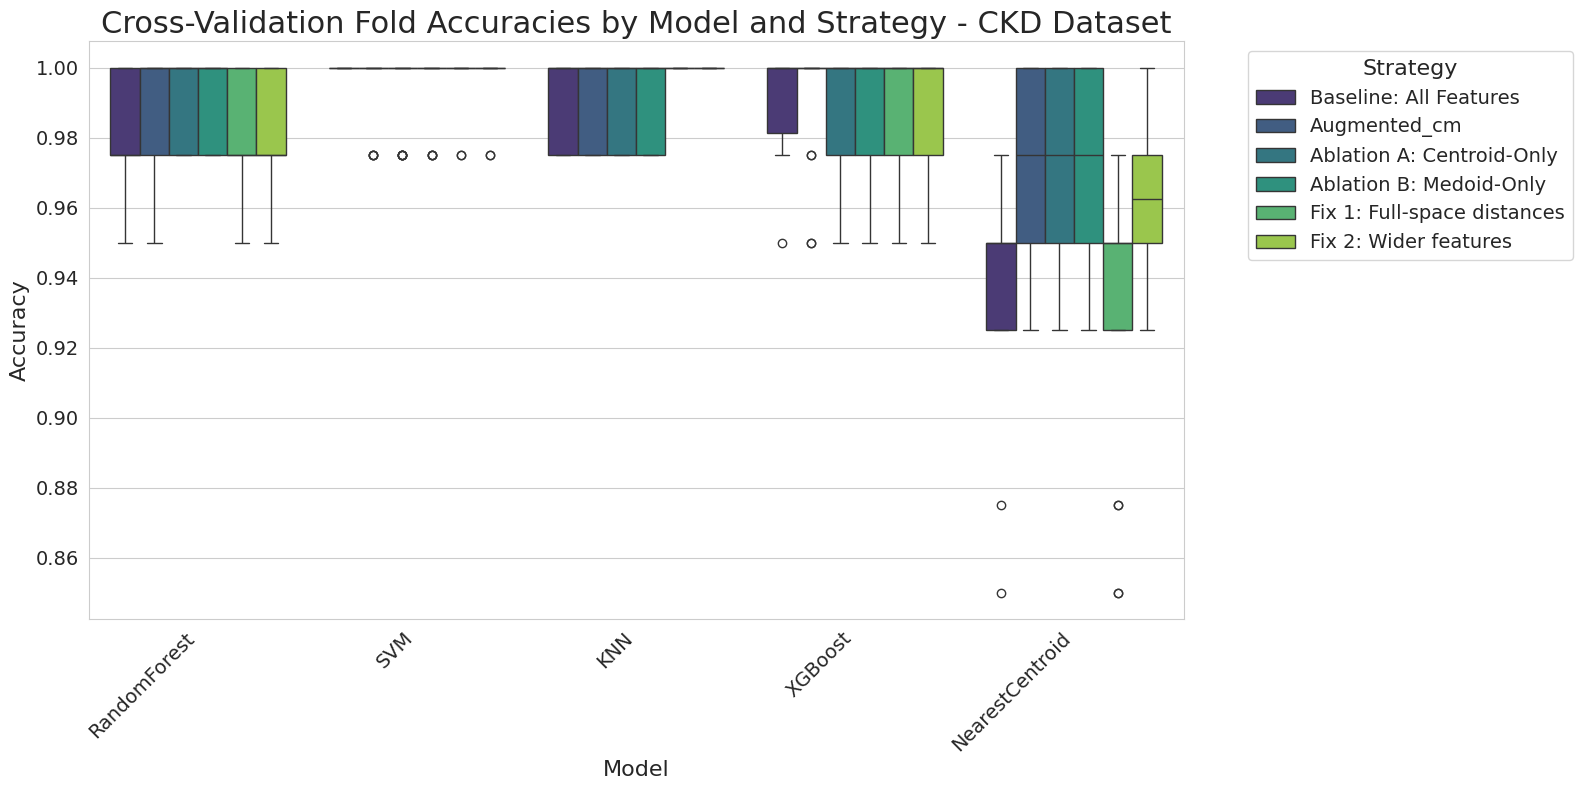

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data for boxplot
boxplot_data = []
for result in all_results:
    if '_fold_accuracies' in result:
        model_name = result['Model']
        strategy_name = result['Strategy']
        for acc in result['_fold_accuracies']:
            boxplot_data.append({'Model': model_name, 'Strategy': strategy_name, 'Accuracy': acc})

boxplot_df = pd.DataFrame(boxplot_data)

# Ensure 'strategy_order' is defined (assuming it's available in the kernel)
# If not, it needs to be defined here or imported from a helper cell
strategy_order = [
    'Baseline: All Features',
    'Augmented_cm',
    'Ablation A: Centroid-Only',
    'Ablation B: Medoid-Only',
    'Fix 1: Full-space distances',
    'Fix 2: Wider features',
]

# Apply the custom order to the 'Strategy' column
boxplot_df['Strategy'] = pd.Categorical(boxplot_df['Strategy'], categories=strategy_order, ordered=True)

# Set up the plot
plt.figure(figsize=(16, 8))
sns.set_style("whitegrid")

# Create the boxplot
sns.boxplot(data=boxplot_df, x='Model', y='Accuracy', hue='Strategy', palette='viridis')

# Customize plot titles and labels
plt.title('Cross-Validation Fold Accuracies by Model and Strategy - CKD Dataset', fontsize=22) # Increased title fontsize
plt.xlabel('Model', fontsize=16) # Increased x-label fontsize
plt.ylabel('Accuracy', fontsize=16) # Increased y-label fontsize
plt.xticks(rotation=45, ha='right', fontsize=14) # Increased x-tick fontsize
plt.yticks(fontsize=14) # Increased y-tick fontsize
plt.legend(title='Strategy', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=14, title_fontsize=16) # Increased legend font sizes
plt.tight_layout()
plt.show()